# Task 2 (Melody Following Chord):

**Task:** generate a melody conditioned on a chord progression.

**Dataset source:** the MIDI files and chord progressions come from **ComMU: Dataset for Combinatorial Music Generation**. ComMU is a symbolic music dataset released by POZAlabs for controllable music generation research. It contains short MIDI clips created by professional composers, paired with musical metadata such as chord progression, key, tempo, time signature, instrument, genre, rhythm, and pitch range. The original ComMU project uses those metadata fields to generate music under many different combinations of musical conditions.

In this project, I use ComMU in a narrower way: I keep the chord progression as the conditioning signal and use the corresponding MIDI melody as the training target. This turns the broader ComMU task into a focused chord-to-melody generation task.

Useful links:

- ComMU GitHub repository: https://github.com/pozalabs/ComMU-code
- ComMU project page: https://pozalabs.github.io/ComMU/
- ComMU paper: https://arxiv.org/abs/2211.09385

This notebook follows these four sections:

1. Exploratory analysis, data collection, preprocessing, and discussion
2. Modeling
3. Evaluation
4. Related work

## Required Python Packages

This notebook uses PyTorch for the neural model and `pretty_midi` for MIDI parsing/synthesis. If the packages are not installed, run the installation cell below once.

Core packages:

```text
torch
pretty_midi
numpy
matplotlib
IPython
```

The installation cell is included for reproducibility. If everything is already installed, you can skip it.


In [37]:
# Uncomment and run this cell if dependencies are missing.
# In many environments, torch is already installed, so installing it can take time.

%pip install torch pretty_midi numpy matplotlib ipython



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
# Dependency check
import importlib.util

required_packages = ['torch', 'pretty_midi', 'numpy', 'matplotlib', 'IPython']
for package in required_packages:
    status = 'OK' if importlib.util.find_spec(package) is not None else 'MISSING'
    print(f'{package:12s} {status}')


torch        OK
pretty_midi  OK
numpy        OK
matplotlib   OK
IPython      OK


## Quick Project Map

```text
midi_generation/
  dataset/
    commu_meta.csv          chord progression CSV
    commu_midi/             raw MIDI files
  preprocessed/             generated JSONL/vocab files
  checkpoints/              trained .pt files
  outputs/                  generated MIDI files
  model/
    chord_features.py       music-theory chord pitch-class features
    encoder.py              Transformer chord encoder
    decoder.py              Transformer melody decoder
    seq2seq.py              full encoder-decoder wrapper
  preprocess.py             CSV + MIDI -> token IDs
  train.py                  training loop
  generate.py               autoregressive melody generation
```

High-level pipeline:

```text
ComMU chord CSV + MIDI files
        |
        v
preprocess.py
        |
        v
train.jsonl / val.jsonl / vocab files
        |
        v
Transformer encoder-decoder training
        |
        v
checkpoints/best.pt
        |
        v
generate.py: chord progression -> generated MIDI
```


In [123]:
from pathlib import Path
import sys, json, ast, math, statistics
from collections import Counter

# This notebook is stored at the repository root.
# The actual project code and data live in midi_generation/.
REPO_ROOT = Path.cwd()
if (REPO_ROOT / 'midi_generation').exists():
    PROJECT_DIR = REPO_ROOT / 'midi_generation'
elif (REPO_ROOT / 'preprocess.py').exists() and (REPO_ROOT / 'model').exists():
    # Fallback if the notebook is opened from inside midi_generation/.
    PROJECT_DIR = REPO_ROOT
    REPO_ROOT = PROJECT_DIR.parent
else:
    raise FileNotFoundError('Could not find midi_generation/ or project files.')

ROOT = PROJECT_DIR
for path in [REPO_ROOT, PROJECT_DIR]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

DATASET_DIR = PROJECT_DIR / 'dataset'
META_PATH = DATASET_DIR / 'commu_meta.csv'
MIDI_ROOT = DATASET_DIR / 'commu_midi'
PREPROCESSED_DIR = PROJECT_DIR / 'preprocessed'
CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints'
OUTPUT_DIR = PROJECT_DIR / 'outputs'

train_path = PREPROCESSED_DIR / 'train.jsonl'
val_path = PREPROCESSED_DIR / 'val.jsonl'
summary_path = PREPROCESSED_DIR / 'summary.json'
chord_vocab_path = PREPROCESSED_DIR / 'chord_vocab.json'
melody_vocab_path = PREPROCESSED_DIR / 'melody_vocab.json'
checkpoint_path = CHECKPOINT_DIR / 'best.pt'

print('commu_meta.csv exists:', META_PATH.exists())
print('commu_midi exists:', MIDI_ROOT.exists())
print('preprocessed exists:', PREPROCESSED_DIR.exists())
print('checkpoints exists:', CHECKPOINT_DIR.exists())


commu_meta.csv exists: True
commu_midi exists: True
preprocessed exists: True
checkpoints exists: True


# 1. Exploratory Analysis, Data Collection, Preprocessing, and Discussion

## 1.1 What does `commu_meta.csv` look like?

Each row stores one chord progression.

Example shape:

```python
"[['Am', 'Am', 'Am', 'Am', 'C', 'C', ...]]"
```

The repetition is important: a row is not merely a list of chord names. It is already a **time-expanded chord sequence**. If `Am` appears 8 times, that means `Am` lasts for 8 model time steps.


In [40]:
def parse_chord_row(line: str) -> list[str]:
    obj = ast.literal_eval(line.strip())
    if isinstance(obj, str):
        obj = ast.literal_eval(obj)
    if isinstance(obj, list) and len(obj) == 1 and isinstance(obj[0], list):
        obj = obj[0]
    if not isinstance(obj, list) or not all(isinstance(chord, str) for chord in obj):
        raise ValueError('Unexpected chord row format')
    return obj

if META_PATH.exists():
    raw_lines = [line for line in META_PATH.read_text().splitlines() if line.strip()]
    chord_sequences = [parse_chord_row(line) for line in raw_lines]
    print('Number of chord progression rows:', len(chord_sequences))
    print('First progression length:', len(chord_sequences[0]))
    print('First 32 chord tokens:')
    print(chord_sequences[0][:32])
else:
    chord_sequences = []
    print('Missing dataset/commu_meta.csv')


Number of chord progression rows: 11144
First progression length: 64
First 32 chord tokens:
['Am', 'Am', 'Am', 'Am', 'Am', 'Am', 'Am', 'Am', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'Dm', 'Dm', 'Dm', 'Dm', 'Dm', 'Dm', 'Dm', 'Dm']


In [41]:
if chord_sequences:
    length_counts = Counter(len(seq) for seq in chord_sequences)
    chord_counts = Counter(chord for seq in chord_sequences for chord in seq)

    print('Unique chord symbols:', len(chord_counts))
    print('Sequence length distribution:')
    for length, count in sorted(length_counts.items()):
        print(f'  {length:3d} time steps: {count:5d} examples')

    print('Most common chord symbols:')
    for chord, count in chord_counts.most_common(20):
        print(f'  {chord:8s} {count:8d}')


Unique chord symbols: 61
Sequence length distribution:
   24 time steps:   101 examples
   32 time steps:  2611 examples
   48 time steps:   670 examples
   64 time steps:  6643 examples
   96 time steps:  1074 examples
  128 time steps:    45 examples
Most common chord symbols:
  Am          91989
  C           86485
  F           75791
  G           59575
  Fmaj7       45553
  Em          37234
  Cmaj7       36120
  Dm7         29040
  Em7         25881
  Am7         23372
  E           19684
  Dm          15190
  G7          11364
  Gsus4       10221
  D            7017
  Fm           5770
  E7           5467
  A#           5048
  Asus4        4472
  G#dim        4376


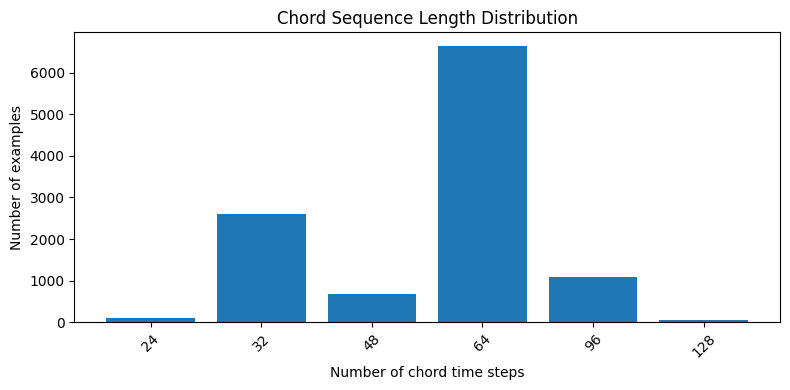

In [42]:
# Optional plot for presentation: chord sequence length distribution.
if chord_sequences:
    try:
        import matplotlib.pyplot as plt
        xs = sorted(length_counts)
        ys = [length_counts[x] for x in xs]
        plt.figure(figsize=(8, 4))
        plt.bar([str(x) for x in xs], ys)
        plt.title('Chord Sequence Length Distribution')
        plt.xlabel('Number of chord time steps')
        plt.ylabel('Number of examples')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print('Plot skipped:', exc)


## 1.3 MIDI files and row alignment

The MIDI files are named like:

```text
commu00001.mid
commu00002.mid
...
```

The preprocessing assumes row `i` in `commu_meta.csv` corresponds to `commu{i:05d}.mid`.

So:

```text
CSV row 1 -> commu00001.mid
CSV row 2 -> commu00002.mid
```


In [43]:
if MIDI_ROOT.exists():
    midi_files = sorted(MIDI_ROOT.rglob('*.mid'))
    print('Number of MIDI files:', len(midi_files))
    print('First 5 MIDI files:')
    for path in midi_files[:5]:
        print(' ', path.relative_to(ROOT))
    print('Last 5 MIDI files:')
    for path in midi_files[-5:]:
        print(' ', path.relative_to(ROOT))
else:
    print('MIDI root missing. Extract commu_midi.tar first if needed.')


Number of MIDI files: 11144
First 5 MIDI files:
  dataset/commu_midi/train/raw/commu00001.mid
  dataset/commu_midi/train/raw/commu00002.mid
  dataset/commu_midi/train/raw/commu00003.mid
  dataset/commu_midi/train/raw/commu00004.mid
  dataset/commu_midi/train/raw/commu00005.mid
Last 5 MIDI files:
  dataset/commu_midi/val/raw/commu11140.mid
  dataset/commu_midi/val/raw/commu11141.mid
  dataset/commu_midi/val/raw/commu11142.mid
  dataset/commu_midi/val/raw/commu11143.mid
  dataset/commu_midi/val/raw/commu11144.mid


## 1.4 Preprocessing: from chords and MIDI to token IDs

The preprocessing script is `preprocess.py`.

It produces:

```text
preprocessed/chord_vocab.json
preprocessed/melody_vocab.json
preprocessed/train.jsonl
preprocessed/val.jsonl
preprocessed/summary.json
```

Each JSONL example contains:

```json
{
  "id": "commu00001",
  "length": 64,
  "chord_ids": [...],
  "melody_input_ids": [...],
  "melody_target_ids": [...]
}
```

### Melody token design

The melody vocabulary uses:

- `<PAD>`: padding for batch training
- `<START>`: first decoder input token
- `REST`: silence
- `HOLD`: continue the previous note
- `NOTE_0` through `NOTE_127`: MIDI pitches

The `HOLD` token was added because repeated note tokens were ambiguous. Without `HOLD`, this could mean either repeated attacks or one sustained note:

```text
NOTE_60 NOTE_60 NOTE_60
```

With `HOLD`, sustained notes become:

```text
NOTE_60 HOLD HOLD
```


### Preprocessing Code: `preprocess.py`

In [126]:
#!/usr/bin/env python3
"""
Preprocess COMMU chord progressions and MIDI melodies.

Outputs:
  preprocessed/chord_vocab.json
  preprocessed/melody_vocab.json
  preprocessed/train.jsonl
  preprocessed/val.jsonl

Each JSONL example contains time-aligned chord IDs and melody IDs. Variable
lengths are preserved so a training Dataset can pad batches later.
"""

from __future__ import annotations

import argparse
import ast
import json
from collections import Counter
from pathlib import Path


PAD = "<PAD>"
UNK = "<UNK>"
START = "<START>"
REST = "REST"
HOLD = "HOLD"


def parse_chord_row(line: str) -> list[str]:
    """Parse one row from commu_meta.csv.

    The file stores each row as a quoted Python-style nested list, for example:
    "[['Am', 'Am', 'C', 'C']]"
    """
    obj = ast.literal_eval(line.strip())
    if isinstance(obj, str):
        obj = ast.literal_eval(obj)
    if isinstance(obj, list) and len(obj) == 1 and isinstance(obj[0], list):
        obj = obj[0]
    if not isinstance(obj, list) or not all(isinstance(chord, str) for chord in obj):
        raise ValueError(f"Unexpected chord row format: {line[:80]!r}")
    return obj


def load_chord_sequences(meta_path: Path) -> list[list[str]]:
    sequences = []
    with meta_path.open("r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            if not line.strip():
                continue
            try:
                sequences.append(parse_chord_row(line))
            except Exception as exc:
                raise ValueError(f"Could not parse {meta_path}:{line_number}") from exc
    return sequences


def build_chord_vocab(sequences: list[list[str]]) -> dict[str, int]:
    counts = Counter(chord for seq in sequences for chord in seq)
    vocab = {PAD: 0, UNK: 1}
    for chord, _ in sorted(counts.items(), key=lambda item: (-item[1], item[0])):
        vocab[chord] = len(vocab)
    return vocab


def build_melody_vocab() -> dict[str, int]:
    vocab = {PAD: 0, START: 1, REST: 2, HOLD: 3}
    for pitch in range(128):
        vocab[f"NOTE_{pitch}"] = len(vocab)
    return vocab


def find_midi_path(midi_root: Path, index: int) -> tuple[str, Path]:
    filename = f"commu{index:05d}.mid"
    matches = list(midi_root.glob(f"*/raw/{filename}"))
    if not matches:
        matches = list(midi_root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find {filename} under {midi_root}")
    path = matches[0]
    split = path.parts[-3] if len(path.parts) >= 3 else "unknown"
    return split, path


def midi_to_melody_tokens(midi_path: Path, steps: int) -> list[str]:
    try:
        import pretty_midi
    except ImportError as exc:
        raise ImportError(
            "pretty_midi is required for MIDI preprocessing. Install it with:\n"
            "  pip install pretty_midi"
        ) from exc

    midi = pretty_midi.PrettyMIDI(str(midi_path))
    instruments = [inst for inst in midi.instruments if not inst.is_drum and inst.notes]
    if not instruments:
        return [REST] * steps

    instrument = max(instruments, key=lambda inst: len(inst.notes))
    end_time = midi.get_end_time()
    if end_time <= 0:
        return [REST] * steps

    step_size = end_time / steps
    tokens = []
    notes = sorted(instrument.notes, key=lambda note: note.start)
    previous_pitch = None

    for step in range(steps):
        start = step * step_size
        end = (step + 1) * step_size
        active = [note.pitch for note in notes if note.start < end and note.end > start]
        if not active:
            tokens.append(REST)
            previous_pitch = None
            continue

        pitch = max(active)
        if pitch == previous_pitch:
            tokens.append(HOLD)
        else:
            tokens.append(f"NOTE_{pitch}")
        previous_pitch = pitch

    return tokens


def write_json(path: Path, data: object) -> None:
    path.write_text(json.dumps(data, indent=2, sort_keys=True) + "\n", encoding="utf-8")


def preprocess(args: argparse.Namespace) -> None:
    meta_path = Path(args.meta)
    midi_root = Path(args.midi_root)
    out_dir = Path(args.out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    chord_sequences = load_chord_sequences(meta_path)
    if args.max_items is not None:
        chord_sequences = chord_sequences[: args.max_items]

    chord_vocab = build_chord_vocab(chord_sequences)
    melody_vocab = build_melody_vocab()

    write_json(out_dir / "chord_vocab.json", chord_vocab)
    write_json(out_dir / "melody_vocab.json", melody_vocab)

    writers = {}
    stats = Counter()
    try:
        for row_index, chords in enumerate(chord_sequences, start=1):
            split, midi_path = find_midi_path(midi_root, row_index)
            out_path = out_dir / f"{split}.jsonl"
            if split not in writers:
                writers[split] = out_path.open("w", encoding="utf-8")

            chord_ids = [chord_vocab.get(chord, chord_vocab[UNK]) for chord in chords]

            if args.chords_only:
                melody_ids = []
                melody_input_ids = []
            else:
                melody_tokens = midi_to_melody_tokens(midi_path, steps=len(chords))
                melody_ids = [melody_vocab[token] for token in melody_tokens]
                melody_input_ids = [melody_vocab[START]] + melody_ids[:-1]

            example = {
                "id": f"commu{row_index:05d}",
                "split": split,
                "midi_path": str(midi_path),
                "length": len(chords),
                "chord_ids": chord_ids,
                "melody_input_ids": melody_input_ids,
                "melody_target_ids": melody_ids,
            }
            writers[split].write(json.dumps(example) + "\n")
            stats[split] += 1
    finally:
        for writer in writers.values():
            writer.close()

    summary = {
        "examples": sum(stats.values()),
        "splits": dict(stats),
        "chord_vocab_size": len(chord_vocab),
        "melody_vocab_size": len(melody_vocab),
        "melody_tokens": {
            "pad": PAD,
            "start": START,
            "rest": REST,
            "hold": HOLD,
        }
    }
    write_json(out_dir / "summary.json", summary)
    print(json.dumps(summary, indent=2))


def main() -> None:
    parser = argparse.ArgumentParser(
        description="Build chord and melody token ID files for chord-conditioned melody generation."
    )
    parser.add_argument("--meta", default="dataset/commu_meta.csv")
    parser.add_argument("--midi-root", default="dataset/commu_midi")
    parser.add_argument("--out-dir", default="preprocessed")
    parser.add_argument("--max-items", type=int, default=None)
    parser.add_argument(
        "--chords-only",
        action="store_true",
        help="Skip MIDI parsing and only write chord IDs. Useful before installing pretty_midi.",
    )
    args = parser.parse_args()
    preprocess(args)

### Run Preprocessing

In [127]:
import subprocess
import tarfile

FORCE_EXTRACT_MIDI = False
FORCE_PREPROCESS = True

def run_command(args, cwd=ROOT):
    print("$", " ".join(str(a) for a in args), flush=True)
    process = subprocess.Popen(
        args,
        cwd=cwd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="", flush=True)
    return_code = process.wait()
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, args)
    return return_code

commu_tar = DATASET_DIR / "commu_midi.tar"
if (FORCE_EXTRACT_MIDI or not MIDI_ROOT.exists()) and commu_tar.exists():
    print("Extracting", commu_tar)
    with tarfile.open(commu_tar) as tar:
        tar.extractall(DATASET_DIR)
elif MIDI_ROOT.exists():
    print("MIDI directory exists")
else:
    raise FileNotFoundError("Need dataset/commu_midi/ or dataset/commu_midi.tar")

if FORCE_PREPROCESS:
    run_command([sys.executable, "preprocess.py"])


MIDI directory exists
$ /usr/local/bin/python3 preprocess.py


{
  "examples": 11144,
  "splits": {
    "train": 10381,
    "val": 763
  },
  "chord_vocab_size": 63,
  "melody_vocab_size": 132,
  "melody_tokens": {
    "pad": "<PAD>",
    "start": "<START>",
    "rest": "REST",
    "hold": "HOLD"
  }
}


### Example: Mapping Chords and Melody Tokens to IDs

The model cannot directly read strings like `Am` or `NOTE_60`, so preprocessing converts every token to an integer ID.

For chords:

```text
Am -> chord_vocab["Am"]
G  -> chord_vocab["G"]
```

For melody:

```text
<START> -> melody_vocab["<START>"]
REST    -> melody_vocab["REST"]
HOLD    -> melody_vocab["HOLD"]
NOTE_60 -> melody_vocab["NOTE_60"]
```

The JSONL training file stores only these integer IDs. During training, the embedding layers turn IDs into vectors.


In [46]:
if chord_vocab_path.exists() and melody_vocab_path.exists():
    chord_vocab = json.loads(chord_vocab_path.read_text())
    melody_vocab = json.loads(melody_vocab_path.read_text())

    chord_demo = ["Am", "G", "F", "E"]
    melody_demo = ["<START>", "NOTE_60", "HOLD", "REST", "NOTE_64"]

    print("Chord token -> ID")
    for chord in chord_demo:
        print(f"  {chord:8s} -> {chord_vocab.get(chord)}")

    print("\nMelody token -> ID")
    for token in melody_demo:
        print(f"  {token:8s} -> {melody_vocab.get(token)}")
else:
    print("Vocab files not found yet. Run preprocessing first.")


Chord token -> ID
  Am       -> 2
  G        -> 5
  F        -> 4
  E        -> 12

Melody token -> ID
  <START>  -> 1
  NOTE_60  -> 64
  HOLD     -> 3
  REST     -> 2
  NOTE_64  -> 68


In [47]:
if train_path.exists() and chord_vocab_path.exists() and melody_vocab_path.exists():
    chord_vocab = json.loads(chord_vocab_path.read_text())
    melody_vocab = json.loads(melody_vocab_path.read_text())
    id_to_chord = {idx: token for token, idx in chord_vocab.items()}
    id_to_melody = {idx: token for token, idx in melody_vocab.items()}

    example = json.loads(train_path.read_text().splitlines()[0])
    print("Raw IDs from first training example:")
    print("  chord_ids first 12:", example["chord_ids"][:12])
    print("  melody_target_ids first 12:", example["melody_target_ids"][:12])

    print("\nDecoded back to readable tokens:")
    print("  chords:", [id_to_chord[i] for i in example["chord_ids"][:12]])
    print("  melody:", [id_to_melody[i] for i in example["melody_target_ids"][:12]])
else:
    print("Run preprocessing first to create train.jsonl and vocab files.")


Raw IDs from first training example:
  chord_ids first 12: [2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3]
  melody_target_ids first 12: [2, 2, 73, 3, 76, 3, 78, 3, 80, 3, 3, 3]

Decoded back to readable tokens:
  chords: ['Am', 'Am', 'Am', 'Am', 'Am', 'Am', 'Am', 'Am', 'C', 'C', 'C', 'C']
  melody: ['REST', 'REST', 'NOTE_69', 'HOLD', 'NOTE_72', 'HOLD', 'NOTE_74', 'HOLD', 'NOTE_76', 'HOLD', 'HOLD', 'HOLD']


In [48]:
if train_path.exists() and melody_vocab_path.exists() and chord_vocab_path.exists():
    first = json.loads(train_path.read_text().splitlines()[0])

    print('Example id:', first['id'])
    print('Length:', first['length'])
    print('These are the actual integer IDs stored in train.jsonl:')
    print('chord_ids first 24:')
    print(first['chord_ids'][:24])
    print('melody_input_ids first 24:')
    print(first['melody_input_ids'][:24])
    print('melody_target_ids first 24:')
    print(first['melody_target_ids'][:24])
else:
    print('Preprocessed files not found. Run preprocessing first.')


Example id: commu00001
Length: 64
These are the actual integer IDs stored in train.jsonl:
chord_ids first 24:
[2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5]
melody_input_ids first 24:
[1, 2, 2, 73, 3, 76, 3, 78, 3, 80, 3, 3, 3, 76, 3, 3, 3, 78, 3, 3, 3, 3, 3, 80]
melody_target_ids first 24:
[2, 2, 73, 3, 76, 3, 78, 3, 80, 3, 3, 3, 76, 3, 3, 3, 78, 3, 3, 3, 3, 3, 80, 3]


# 2. Modeling

## 2.1 ML formulation

This task is conditional sequence modeling. The chord progression is the condition, and the melody is generated autoregressively.

The chord sequence is:

$$
\mathbf{c} = (c_1, c_2, \ldots, c_T)
$$

The melody sequence is:

$$
\mathbf{m} = (m_1, m_2, \ldots, m_T)
$$

At time step $t$, the model estimates:

$$
P(m_t \mid \mathbf{c}, m_1, \ldots, m_{t-1})
$$

Training minimizes cross-entropy loss:

$$
\mathcal{L} = -\sum_{t=1}^{T} \log P(m_t^{\text{target}} \mid \mathbf{c}, m_{<t})
$$

Basically, the model sees the full chord progression and the melody so far, then predicts the next melody token.


## 2.2 Token Embeddings Used by the Model

There are two main embedding tables:

```text
chord token ID  -> chord embedding vector
melody token ID -> melody embedding vector
```

In the default model, both embeddings have size:

```text
d_model = 128
```

So each chord ID becomes a 128-dimensional vector, and each melody ID also becomes a 128-dimensional vector. These vectors are learned during training.

The model also adds **positional encoding**, because the same token can mean different things depending on where it appears. For example, `Am` at the beginning of a phrase and `Am` after an `E` chord should not necessarily have identical contextual meaning.

### Small addition: chord pitch-class features

In addition to the learned chord ID embedding, I add a small music-theory feature for chords. Each chord gets a 12-dimensional pitch-class vector. For example:

```text
Am = A C E
```

This helps the model know that `Am` contains the notes A, C, and E. The feature vector is projected to the model dimension and added to the learned chord embedding. This is a small improvement, but the main representation still comes from the learned embeddings.


### Chord Feature Code: `model/chord_features.py`

In [49]:
import torch


ROOT_TO_PC = {
    "C": 0,
    "C#": 1,
    "Db": 1,
    "D": 2,
    "D#": 3,
    "Eb": 3,
    "E": 4,
    "F": 5,
    "F#": 6,
    "Gb": 6,
    "G": 7,
    "G#": 8,
    "Ab": 8,
    "A": 9,
    "A#": 10,
    "Bb": 10,
    "B": 11,
}

QUALITY_INTERVALS = {
    "": [0, 4, 7],
    "m": [0, 3, 7],
    "7": [0, 4, 7, 10],
    "maj7": [0, 4, 7, 11],
    "m7": [0, 3, 7, 10],
    "dim": [0, 3, 6],
    "+": [0, 4, 8],
    "sus4": [0, 5, 7],
    "m7b5": [0, 3, 6, 10],
}


def parse_chord(chord: str) -> tuple[str, str]:
    if len(chord) >= 2 and chord[1] in {"#", "b"}:
        return chord[:2], chord[2:]
    return chord[:1], chord[1:]


def chord_pitch_class_vector(chord: str) -> list[float]:
    vector = [0.0] * 12
    root, quality = parse_chord(chord)
    root_pc = ROOT_TO_PC.get(root)
    intervals = QUALITY_INTERVALS.get(quality)
    if root_pc is None or intervals is None:
        return vector

    for interval in intervals:
        vector[(root_pc + interval) % 12] = 1.0
    return vector


def build_chord_feature_matrix(chord_vocab: dict[str, int]) -> torch.Tensor:
    matrix = torch.zeros(len(chord_vocab), 12, dtype=torch.float32)
    for chord, chord_id in chord_vocab.items():
        matrix[chord_id] = torch.tensor(chord_pitch_class_vector(chord))
    return matrix


In [50]:
if chord_vocab_path.exists():
    from midi_generation.model.chord_features import chord_pitch_class_vector
    for chord in ['Am', 'G', 'F', 'E', 'Cmaj7', 'Dm7', 'F#m7b5']:
        print(chord, chord_pitch_class_vector(chord))
else:
    print('Chord vocab not found yet.')


Am [1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]
G [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]
F [1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]
E [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0]
Cmaj7 [1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]
Dm7 [1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]
F#m7b5 [1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0]


## 2.3 Encoder code walkthrough

The chord encoder does this:

```text
chord_ids
  -> learned embedding
  -> optional chord pitch-class feature projection
  -> sinusoidal positional encoding
  -> TransformerEncoder
  -> chord memory
```

The output is **one contextual vector per chord time step**, not one collapsed vector.

Shape:

```text
[batch, chord_time, d_model]
```


### Encoder Code: `model/encoder.py`

In [51]:
import math

import torch
from torch import nn


class SinusoidalPositionalEncoding(nn.Module):
    """Adds fixed positional information to token embeddings. 
    Need this so that same chords following different sequences
    map to different contexts."""

    def __init__(self, d_model: int, max_len: int = 1024, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len]
        return self.dropout(x)


class ChordEncoder(nn.Module):
    """Transformer encoder for chord progressions.

    Args:
        chord_vocab_size: Number of chord tokens, including PAD/UNK.
        d_model: Shared hidden size used by encoder and decoder.
        num_layers: Number of Transformer encoder layers.
        num_heads: Number of attention heads.
        dim_feedforward: Size of the feed-forward layer inside each block.
        dropout: Dropout probability.
        pad_id: Padding token ID. In the current preprocessing, PAD is 0.
        max_len: Maximum chord sequence length supported by positional encoding.

    Input:
        chord_ids: LongTensor shaped [batch, chord_time]

    Output:
        memory: FloatTensor shaped [batch, chord_time, d_model]
        padding_mask: BoolTensor shaped [batch, chord_time], True where padded
    """

    def __init__(
        self,
        chord_vocab_size: int,
        d_model: int = 128,
        num_layers: int = 4,
        num_heads: int = 4,
        dim_feedforward: int = 512,
        dropout: float = 0.1,
        pad_id: int = 0,
        max_len: int = 1024,
        use_chord_features: bool = False,
        chord_feature_matrix: torch.Tensor | None = None,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model
        self.use_chord_features = use_chord_features

        self.embedding = nn.Embedding(
            num_embeddings=chord_vocab_size,
            embedding_dim=d_model,
            padding_idx=pad_id,
        )
        if use_chord_features:
            if chord_feature_matrix is None:
                chord_feature_matrix = torch.zeros(chord_vocab_size, 12)
            self.register_buffer("chord_feature_matrix", chord_feature_matrix.float())
            self.chord_feature_proj = nn.Linear(12, d_model, bias=False)
        self.position = SinusoidalPositionalEncoding(d_model, max_len, dropout)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            layer,
            num_layers=num_layers,
            enable_nested_tensor=False,
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, chord_ids: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        padding_mask = chord_ids.eq(self.pad_id)

        x = self.embedding(chord_ids) * math.sqrt(self.d_model)
        if self.use_chord_features:
            chord_features = self.chord_feature_matrix[chord_ids]
            x = x + self.chord_feature_proj(chord_features)
        x = self.position(x)
        memory = self.encoder(x, src_key_padding_mask=padding_mask)
        memory = self.norm(memory)

        return memory, padding_mask


## 2.4 Decoder code walkthrough

The melody decoder does this:

```text
melody_input_ids
  -> melody embedding
  -> positional encoding
  -> causal self-attention over previous melody tokens
  -> cross-attention to chord memory
  -> output logits over melody vocabulary
```

The causal mask prevents the decoder from looking at future melody tokens during training.


### Decoder Code: `model/decoder.py`

In [52]:
import math

import torch
from torch import nn

from midi_generation.model.encoder import SinusoidalPositionalEncoding


class MelodyDecoder(nn.Module):
    """Transformer decoder for autoregressive melody prediction.

    Args:
        melody_vocab_size: Number of melody tokens, including PAD/START/REST.
        d_model: Shared hidden size used by encoder and decoder.
        num_layers: Number of Transformer decoder layers.
        num_heads: Number of attention heads.
        dim_feedforward: Size of the feed-forward layer inside each block.
        dropout: Dropout probability.
        pad_id: Padding token ID. In the current preprocessing, PAD is 0.
        max_len: Maximum melody sequence length supported by positional encoding.

    Inputs:
        melody_input_ids: LongTensor shaped [batch, melody_time]
        chord_memory: FloatTensor shaped [batch, chord_time, d_model]
        chord_padding_mask: BoolTensor shaped [batch, chord_time], True where padded

    Output:
        logits: FloatTensor shaped [batch, melody_time, melody_vocab_size]
    """

    def __init__(
        self,
        melody_vocab_size: int,
        d_model: int = 128,
        num_layers: int = 4,
        num_heads: int = 4,
        dim_feedforward: int = 512,
        dropout: float = 0.1,
        pad_id: int = 0,
        max_len: int = 1024,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model

        self.embedding = nn.Embedding(
            num_embeddings=melody_vocab_size,
            embedding_dim=d_model,
            padding_idx=pad_id,
        )
        self.position = SinusoidalPositionalEncoding(d_model, max_len, dropout)

        layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.decoder = nn.TransformerDecoder(layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.output = nn.Linear(d_model, melody_vocab_size)

    def forward(
        self,
        melody_input_ids: torch.Tensor,
        chord_memory: torch.Tensor,
        chord_padding_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        melody_padding_mask = melody_input_ids.eq(self.pad_id)
        causal_mask = self._causal_mask(
            melody_input_ids.size(1), device=melody_input_ids.device
        )

        x = self.embedding(melody_input_ids) * math.sqrt(self.d_model)
        x = self.position(x)

        hidden = self.decoder(
            tgt=x,
            memory=chord_memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=melody_padding_mask,
            memory_key_padding_mask=chord_padding_mask,
        )
        hidden = self.norm(hidden)
        return self.output(hidden)

    @staticmethod
    def _causal_mask(size: int, device: torch.device) -> torch.Tensor:
        return torch.triu(
            torch.ones((size, size), dtype=torch.bool, device=device),
            diagonal=1,
        )


## 2.5 Full seq2seq model

`model/seq2seq.py` connects the encoder and decoder.

Forward pass:

```python
chord_memory, chord_padding_mask = encoder(chord_ids)
logits = decoder(melody_input_ids, chord_memory, chord_padding_mask)
```


### Seq2Seq Wrapper Code: `model/seq2seq.py`

In [53]:
from torch import nn

from midi_generation.model.decoder import MelodyDecoder
from midi_generation.model.encoder import ChordEncoder


class ChordConditionedMelodyModel(nn.Module):
    """Encoder-decoder model for chord-conditioned melody generation."""

    def __init__(
        self,
        chord_vocab_size: int,
        melody_vocab_size: int,
        d_model: int = 128,
        encoder_layers: int = 4,
        decoder_layers: int = 4,
        num_heads: int = 4,
        dim_feedforward: int = 512,
        dropout: float = 0.1,
        pad_id: int = 0,
        max_len: int = 1024,
        use_chord_features: bool = False,
        chord_feature_matrix=None,
    ):
        super().__init__()
        self.encoder = ChordEncoder(
            chord_vocab_size=chord_vocab_size,
            d_model=d_model,
            num_layers=encoder_layers,
            num_heads=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            pad_id=pad_id,
            max_len=max_len,
            use_chord_features=use_chord_features,
            chord_feature_matrix=chord_feature_matrix,
        )
        self.decoder = MelodyDecoder(
            melody_vocab_size=melody_vocab_size,
            d_model=d_model,
            num_layers=decoder_layers,
            num_heads=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            pad_id=pad_id,
            max_len=max_len,
        )

    def forward(self, chord_ids, melody_input_ids):
        chord_memory, chord_padding_mask = self.encoder(chord_ids)
        return self.decoder(
            melody_input_ids=melody_input_ids,
            chord_memory=chord_memory,
            chord_padding_mask=chord_padding_mask,
        )


## 2.6 Training

Training uses teacher forcing:

```text
melody_input_ids  = <START>, m_1, m_2, ..., m_{T-1}
melody_target_ids = m_1,     m_2, m_3, ..., m_T
```

For each batch:

1. Read examples from JSONL.
2. Pad variable-length sequences.
3. Run model forward pass.
4. Compute cross-entropy loss.
5. Ignore `<PAD>` tokens.
6. Backpropagate and update weights.
7. Save `last.pt` and `best.pt`.


### Training Code: `train.py`

In [54]:
#!/usr/bin/env python3

import argparse
import json
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from midi_generation.model.chord_features import build_chord_feature_matrix
from midi_generation.model.seq2seq import ChordConditionedMelodyModel


PAD_ID = 0


class MelodyJsonlDataset(Dataset):
    def __init__(self, path: str | Path, max_items: int | None = None):
        self.examples = []
        with Path(path).open("r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                self.examples.append(json.loads(line))
                if max_items is not None and len(self.examples) >= max_items:
                    break

    def __len__(self) -> int:
        return len(self.examples)

    def __getitem__(self, index: int) -> dict:
        return self.examples[index]


def pad_sequence(values: list[list[int]], pad_id: int = PAD_ID) -> torch.Tensor:
    max_len = max(len(item) for item in values)
    padded = [item + [pad_id] * (max_len - len(item)) for item in values]
    return torch.tensor(padded, dtype=torch.long)


def collate_batch(examples: list[dict]) -> dict[str, torch.Tensor | list[str]]:
    return {
        "ids": [example["id"] for example in examples],
        "chord_ids": pad_sequence([example["chord_ids"] for example in examples]),
        "melody_input_ids": pad_sequence(
            [example["melody_input_ids"] for example in examples]
        ),
        "melody_target_ids": pad_sequence(
            [example["melody_target_ids"] for example in examples]
        ),
    }


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
    optimizer: torch.optim.Optimizer | None = None,
) -> float:
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_tokens = 0

    for batch in loader:
        chord_ids = batch["chord_ids"].to(device)
        melody_input_ids = batch["melody_input_ids"].to(device)
        melody_target_ids = batch["melody_target_ids"].to(device)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(chord_ids, melody_input_ids)
            loss = loss_fn(
                logits.reshape(-1, logits.size(-1)),
                melody_target_ids.reshape(-1),
            )

            if is_training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        token_count = melody_target_ids.ne(PAD_ID).sum().item()
        total_loss += loss.item() * token_count
        total_tokens += token_count

    return total_loss / max(total_tokens, 1)


def load_vocab_size(path: str | Path) -> int:
    with Path(path).open("r", encoding="utf-8") as f:
        return len(json.load(f))


def load_vocab(path: str | Path) -> dict[str, int]:
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def save_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    args: argparse.Namespace,
    epoch: int,
    train_loss: float,
    val_loss: float,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "args": vars(args),
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
        },
        path,
    )


def main() -> None:
    parser = argparse.ArgumentParser(
        description="Train a chord-conditioned encoder-decoder melody model."
    )
    parser.add_argument("--train-jsonl", default="preprocessed/train.jsonl")
    parser.add_argument("--val-jsonl", default="preprocessed/val.jsonl")
    parser.add_argument("--chord-vocab", default="preprocessed/chord_vocab.json")
    parser.add_argument("--melody-vocab", default="preprocessed/melody_vocab.json")
    parser.add_argument("--checkpoint-dir", default="checkpoints")
    parser.add_argument("--epochs", type=int, default=10)
    parser.add_argument("--batch-size", type=int, default=32)
    parser.add_argument("--lr", type=float, default=3e-4)
    parser.add_argument("--d-model", type=int, default=128)
    parser.add_argument("--encoder-layers", type=int, default=4)
    parser.add_argument("--decoder-layers", type=int, default=4)
    parser.add_argument("--num-heads", type=int, default=4)
    parser.add_argument("--dim-feedforward", type=int, default=512)
    parser.add_argument("--dropout", type=float, default=0.1)
    parser.add_argument("--max-len", type=int, default=1024)
    parser.add_argument(
        "--use-chord-features",
        action=argparse.BooleanOptionalAction,
        default=True,
        help="Add pitch-class chord features to the learned chord ID embeddings.",
    )
    parser.add_argument("--max-train-items", type=int, default=None)
    parser.add_argument("--max-val-items", type=int, default=None)
    parser.add_argument("--num-workers", type=int, default=0)
    parser.add_argument("--device", default="auto", choices=["auto", "cpu", "cuda", "mps"])
    args = parser.parse_args()

    if args.device == "auto":
        if torch.cuda.is_available():
            device = torch.device("cuda")
        elif torch.backends.mps.is_available():
            device = torch.device("mps")
        else:
            device = torch.device("cpu")
    else:
        device = torch.device(args.device)

    chord_vocab = load_vocab(args.chord_vocab)
    chord_vocab_size = len(chord_vocab)
    melody_vocab_size = load_vocab_size(args.melody_vocab)
    chord_feature_matrix = (
        build_chord_feature_matrix(chord_vocab) if args.use_chord_features else None
    )

    train_data = MelodyJsonlDataset(args.train_jsonl, max_items=args.max_train_items)
    val_data = MelodyJsonlDataset(args.val_jsonl, max_items=args.max_val_items)

    train_loader = DataLoader(
        train_data,
        batch_size=args.batch_size,
        shuffle=True,
        collate_fn=collate_batch,
        num_workers=args.num_workers,
    )
    val_loader = DataLoader(
        val_data,
        batch_size=args.batch_size,
        shuffle=False,
        collate_fn=collate_batch,
        num_workers=args.num_workers,
    )

    model = ChordConditionedMelodyModel(
        chord_vocab_size=chord_vocab_size,
        melody_vocab_size=melody_vocab_size,
        d_model=args.d_model,
        encoder_layers=args.encoder_layers,
        decoder_layers=args.decoder_layers,
        num_heads=args.num_heads,
        dim_feedforward=args.dim_feedforward,
        dropout=args.dropout,
        pad_id=PAD_ID,
        max_len=args.max_len,
        use_chord_features=args.use_chord_features,
        chord_feature_matrix=chord_feature_matrix,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr)
    loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID)

    print(f"device: {device}")
    print(f"train examples: {len(train_data)}")
    print(f"val examples: {len(val_data)}")
    print(f"chord vocab: {chord_vocab_size}")
    print(f"melody vocab: {melody_vocab_size}")

    best_val_loss = float("inf")
    checkpoint_dir = Path(args.checkpoint_dir)

    for epoch in range(1, args.epochs + 1):
        train_loss = run_epoch(model, train_loader, loss_fn, device, optimizer)
        val_loss = run_epoch(model, val_loader, loss_fn, device)

        print(
            f"epoch {epoch:03d} | "
            f"train_loss {train_loss:.4f} | "
            f"val_loss {val_loss:.4f}"
        )

        save_checkpoint(
            checkpoint_dir / "last.pt",
            model,
            optimizer,
            args,
            epoch,
            train_loss,
            val_loss,
        )
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(
                checkpoint_dir / "best.pt",
                model,
                optimizer,
                args,
                epoch,
                train_loss,
                val_loss,
            )

## 2.8 Training command

The main training command is:

```bash
python3 midi_generation/train.py --epochs 30 --batch-size 32
```

### Run Training

This belongs in Section 2 because training is part of modeling. By default, this cell trains from scratch and overwrites `checkpoints/best.pt` and `checkpoints/last.pt`.

For a quick test, set `TRAIN_EPOCHS = 1`. For the final report, use the normal setting.


In [55]:
FORCE_TRAIN = True
TRAIN_EPOCHS = 30
TRAIN_BATCH_SIZE = 32

if FORCE_TRAIN:
    run_command([
        sys.executable, "train.py",
        "--epochs", str(TRAIN_EPOCHS),
        "--batch-size", str(TRAIN_BATCH_SIZE),
    ])


$ /usr/local/bin/python3 train.py --epochs 30 --batch-size 32
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.0.7) or chardet (7.4.3)/charset_normalizer (3.3.0) doesn't match a supported version!
  warnings.warn(
device: mps
train examples: 10381
val examples: 763
chord vocab: 63
melody vocab: 132
epoch 001 | train_loss 1.6985 | val_loss 1.2157
epoch 002 | train_loss 1.4257 | val_loss 1.1752
epoch 003 | train_loss 1.3755 | val_loss 1.1493
epoch 004 | train_loss 1.3455 | val_loss 1.1324
epoch 005 | train_loss 1.3232 | val_loss 1.1219
epoch 006 | train_loss 1.3047 | val_loss 1.1154
epoch 007 | train_loss 1.2890 | val_loss 1.1011
epoch 008 | train_loss 1.2740 | val_loss 1.0959
epoch 009 | train_loss 1.2609 | val_loss 1.0881
epoch 010 | train_loss 1.2482 | val_loss 1.0822
epoch 011 | train_loss 1.2353 | val_loss 1.0789
epoch 012 | train_loss 1.2257 | val_loss 1.0720
epoch 013 | train_loss 1.2141

In [128]:
# Inspect checkpoint metadata if a trained checkpoint exists.
checkpoint_path = CHECKPOINT_DIR / 'best.pt'
if checkpoint_path.exists():
    import torch
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    print('Epoch:', ckpt.get('epoch'))
    print('Train loss:', ckpt.get('train_loss'))
    print('Validation loss:', ckpt.get('val_loss'))
    print('Training args:')
    for key in ['epochs', 'batch_size', 'lr', 'd_model', 'encoder_layers', 'decoder_layers', 'num_heads', 'use_chord_features']:
        print(f'  {key}:', ckpt.get('args', {}).get(key))
else:
    print('No best.pt checkpoint found yet.')


Epoch: 27
Train loss: 1.1056837447624388
Validation loss: 1.0388616226215681
Training args:
  epochs: 30
  batch_size: 32
  lr: 0.0003
  d_model: 128
  encoder_layers: 4
  decoder_layers: 4
  num_heads: 4
  use_chord_features: True


## 2.9 Generation code walkthrough

Generation is autoregressive:

```text
1. User enters chord progression.
2. Convert chords to chord IDs.
3. Start melody with <START>.
4. Ask model for next-token logits.
5. Sample next token with temperature/top-k.
6. Append token.
7. Repeat until the melody length matches the chord sequence length.
8. Convert NOTE/HOLD/REST tokens to MIDI.
```

Important generation controls:

- `--steps-per-chord`: expands compact progressions like `Am-G-F-E`
- `--temperature`: controls randomness
- `--top-k`: samples only from the top-k tokens
- `--chord-tone-bias`: boosts notes that belong to the active chord
- `--min-pitch`, `--max-pitch`: constrain pitch range


### Generation Code: `generate.py`

In [95]:
#!/usr/bin/env python3

import argparse
import json
from pathlib import Path
from statistics import mean

import torch

from midi_generation.model.chord_features import build_chord_feature_matrix
from midi_generation.model.seq2seq import ChordConditionedMelodyModel


PAD_ID = 0
START = "<START>"
REST = "REST"
HOLD = "HOLD"

ROOT_TO_PC = {
    "C": 0,
    "C#": 1,
    "Db": 1,
    "D": 2,
    "D#": 3,
    "Eb": 3,
    "E": 4,
    "F": 5,
    "F#": 6,
    "Gb": 6,
    "G": 7,
    "G#": 8,
    "Ab": 8,
    "A": 9,
    "A#": 10,
    "Bb": 10,
    "B": 11,
}

QUALITY_INTERVALS = {
    "": [0, 4, 7],
    "m": [0, 3, 7],
    "7": [0, 4, 7, 10],
    "maj7": [0, 4, 7, 11],
    "m7": [0, 3, 7, 10],
    "dim": [0, 3, 6],
    "+": [0, 4, 8],
    "sus4": [0, 5, 7],
    "m7b5": [0, 3, 6, 10],
}


def load_json(path: str | Path) -> dict:
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def invert_vocab(vocab: dict[str, int]) -> dict[int, str]:
    return {idx: token for token, idx in vocab.items()}


def parse_chord(chord: str) -> tuple[str, str]:
    if len(chord) >= 2 and chord[1] in {"#", "b"}:
        return chord[:2], chord[2:]
    return chord[:1], chord[1:]


def chord_pitch_classes(chord: str) -> set[int]:
    root, quality = parse_chord(chord)
    root_pc = ROOT_TO_PC.get(root)
    intervals = QUALITY_INTERVALS.get(quality)
    if root_pc is None or intervals is None:
        return set()
    return {(root_pc + interval) % 12 for interval in intervals}


def build_note_id_maps(melody_vocab: dict[str, int]) -> tuple[dict[int, int], dict[int, int]]:
    id_to_pitch = {}
    pitch_to_id = {}
    for token, token_id in melody_vocab.items():
        if token.startswith("NOTE_"):
            pitch = int(token.split("_", 1)[1])
            id_to_pitch[token_id] = pitch
            pitch_to_id[pitch] = token_id
    return id_to_pitch, pitch_to_id


def build_chord_tone_ids(
    chord: str,
    pitch_to_id: dict[int, int],
    min_pitch: int,
    max_pitch: int,
) -> set[int]:
    pitch_classes = chord_pitch_classes(chord)
    if not pitch_classes:
        return set()
    return {
        token_id
        for pitch, token_id in pitch_to_id.items()
        if min_pitch <= pitch <= max_pitch and pitch % 12 in pitch_classes
    }


def expand_chords(chords: list[str], steps_per_chord: int) -> list[str]:
    expanded = []
    for chord in chords:
        expanded.extend([chord] * steps_per_chord)
    return expanded


def normalize_chord_args(chords: list[str]) -> list[str]:
    normalized = []
    for item in chords:
        parts = [part.strip() for part in item.replace(",", "-").split("-")]
        normalized.extend(part for part in parts if part)
    return normalized


def choose_device(name: str) -> torch.device:
    if name == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")
        if torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")
    return torch.device(name)


def build_model(
    checkpoint: dict,
    chord_vocab: dict[str, int],
    melody_vocab_size: int,
) -> ChordConditionedMelodyModel:
    args = checkpoint.get("args", {})
    use_chord_features = args.get("use_chord_features", False)
    chord_feature_matrix = (
        build_chord_feature_matrix(chord_vocab) if use_chord_features else None
    )
    return ChordConditionedMelodyModel(
        chord_vocab_size=len(chord_vocab),
        melody_vocab_size=melody_vocab_size,
        d_model=args.get("d_model", 128),
        encoder_layers=args.get("encoder_layers", 4),
        decoder_layers=args.get("decoder_layers", 4),
        num_heads=args.get("num_heads", 4),
        dim_feedforward=args.get("dim_feedforward", 512),
        dropout=args.get("dropout", 0.1),
        pad_id=PAD_ID,
        max_len=args.get("max_len", 1024),
        use_chord_features=use_chord_features,
        chord_feature_matrix=chord_feature_matrix,
    )


def banned_ngram_tokens(melody_ids: list[int], ngram_size: int) -> set[int]:
    if ngram_size <= 1 or len(melody_ids) < ngram_size - 1:
        return set()

    prefix = tuple(melody_ids[-(ngram_size - 1):])
    banned = set()
    for idx in range(len(melody_ids) - ngram_size + 1):
        ngram = tuple(melody_ids[idx: idx + ngram_size])
        if ngram[:-1] == prefix:
            banned.add(ngram[-1])
    return banned


def sample_next_token(
    logits: torch.Tensor,
    temperature: float,
    top_k: int,
    melody_ids: list[int],
    rest_id: int,
    id_to_pitch: dict[int, int],
    min_pitch: int,
    max_pitch: int,
    chord_tone_ids: set[int],
    chord_tone_bias: float,
    repetition_penalty: float,
    immediate_repeat_penalty: float,
    max_repeat: int,
    no_repeat_ngram_size: int,
) -> int:
    logits = logits.clone()

    for token_id, pitch in id_to_pitch.items():
        if pitch < min_pitch or pitch > max_pitch:
            logits[token_id] = float("-inf")

    if chord_tone_bias != 0 and chord_tone_ids:
        for token_id in chord_tone_ids:
            logits[token_id] = logits[token_id] + chord_tone_bias

    if melody_ids and repetition_penalty > 1.0:
        for token_id in set(melody_ids[-16:]):
            if token_id != rest_id:
                logits[token_id] = logits[token_id] / repetition_penalty

    if melody_ids and immediate_repeat_penalty > 1.0 and melody_ids[-1] != rest_id:
        logits[melody_ids[-1]] = logits[melody_ids[-1]] / immediate_repeat_penalty

    if max_repeat > 0 and len(melody_ids) >= max_repeat:
        recent = melody_ids[-max_repeat:]
        if len(set(recent)) == 1 and recent[0] != rest_id:
            logits[recent[0]] = float("-inf")

    for token_id in banned_ngram_tokens(melody_ids, no_repeat_ngram_size):
        if token_id != rest_id:
            logits[token_id] = float("-inf")

    if temperature <= 0:
        return int(torch.argmax(logits).item())

    logits = logits / temperature

    if top_k > 0:
        values, indices = torch.topk(logits, k=min(top_k, logits.size(-1)))
        probs = torch.softmax(values, dim=-1)
        choice = torch.multinomial(probs, num_samples=1)
        return int(indices[choice].item())

    probs = torch.softmax(logits, dim=-1)
    return int(torch.multinomial(probs, num_samples=1).item())


def generate_melody_ids(
    model: ChordConditionedMelodyModel,
    chord_ids: list[int],
    expanded_chords: list[str],
    start_id: int,
    rest_id: int,
    id_to_pitch: dict[int, int],
    pitch_to_id: dict[int, int],
    device: torch.device,
    temperature: float,
    top_k: int,
    min_pitch: int,
    max_pitch: int,
    chord_tone_bias: float,
    repetition_penalty: float,
    immediate_repeat_penalty: float,
    max_repeat: int,
    no_repeat_ngram_size: int,
) -> list[int]:
    model.eval()
    chord_tensor = torch.tensor([chord_ids], dtype=torch.long, device=device)
    melody_ids = [start_id]

    with torch.no_grad():
        for _ in range(len(chord_ids)):
            step = len(melody_ids) - 1
            chord_tone_ids = build_chord_tone_ids(
                expanded_chords[step],
                pitch_to_id,
                min_pitch,
                max_pitch,
            )
            melody_tensor = torch.tensor([melody_ids], dtype=torch.long, device=device)
            logits = model(chord_tensor, melody_tensor)
            next_logits = logits[0, -1]
            next_id = sample_next_token(
                next_logits,
                temperature,
                top_k,
                melody_ids,
                rest_id,
                id_to_pitch,
                min_pitch,
                max_pitch,
                chord_tone_ids,
                chord_tone_bias,
                repetition_penalty,
                immediate_repeat_penalty,
                max_repeat,
                no_repeat_ngram_size,
            )
            melody_ids.append(next_id)

    return melody_ids[1:]


def melody_stats(melody_ids: list[int], rest_id: int, id_to_pitch: dict[int, int]) -> dict:
    note_ids = [token_id for token_id in melody_ids if token_id in id_to_pitch]
    if not note_ids:
        return {
            "num_notes": 0,
            "unique_notes": 0,
            "unique_ratio": 0.0,
            "rest_ratio": 1.0,
            "adjacent_repeat_ratio": 1.0,
            "longest_run": 0,
            "score": -999.0,
        }

    adjacent_repeats = sum(
        1 for prev, curr in zip(note_ids, note_ids[1:]) if prev == curr
    )
    runs = []
    current_run = 1
    for prev, curr in zip(note_ids, note_ids[1:]):
        if prev == curr:
            current_run += 1
        else:
            runs.append(current_run)
            current_run = 1
    runs.append(current_run)

    unique_notes = len(set(note_ids))
    unique_ratio = unique_notes / len(note_ids)
    rest_ratio = melody_ids.count(rest_id) / max(len(melody_ids), 1)
    adjacent_repeat_ratio = adjacent_repeats / max(len(note_ids) - 1, 1)
    pitch_values = [id_to_pitch[token_id] for token_id in note_ids]
    contour_steps = [abs(b - a) for a, b in zip(pitch_values, pitch_values[1:])]
    avg_motion = mean(contour_steps) if contour_steps else 0.0

    score = (
        unique_ratio * 3.0
        - adjacent_repeat_ratio * 0.75
        - rest_ratio * 1.5
        + min(avg_motion, 7.0) * 0.08
    )

    return {
        "num_notes": len(note_ids),
        "unique_notes": unique_notes,
        "unique_ratio": unique_ratio,
        "rest_ratio": rest_ratio,
        "adjacent_repeat_ratio": adjacent_repeat_ratio,
        "longest_run": max(runs),
        "score": score,
    }


NOTE_NAMES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]


def pitch_name(pitch: int) -> str:
    return f"{NOTE_NAMES[pitch % 12]}{pitch // 12 - 1}"


def note_sort_key(note_name: str) -> tuple[int, int]:
    octave = int(note_name[-1])
    pitch_class = note_name[:-1]
    return octave, NOTE_NAMES.index(pitch_class)


def format_pitch_classes(pitch_classes: set[int]) -> str:
    return "/".join(NOTE_NAMES[pc] for pc in sorted(pitch_classes)) or "unknown"


def analyze_chord_fit(
    melody_ids: list[int],
    expanded_chords: list[str],
    id_to_pitch: dict[int, int],
) -> dict:
    note_rows = []
    sections = []

    for step, (token_id, chord) in enumerate(zip(melody_ids, expanded_chords)):
        if not sections or sections[-1]["chord"] != chord:
            sections.append(
                {
                    "chord": chord,
                    "start_step": step,
                    "end_step": step + 1,
                    "notes": [],
                }
            )
        else:
            sections[-1]["end_step"] = step + 1

        if token_id not in id_to_pitch:
            continue

        pitch = id_to_pitch[token_id]
        pitch_classes = chord_pitch_classes(chord)
        in_chord = bool(pitch_classes) and pitch % 12 in pitch_classes
        row = {
            "step": step,
            "chord": chord,
            "pitch": pitch,
            "note": pitch_name(pitch),
            "in_chord": in_chord,
            "tones": format_pitch_classes(pitch_classes),
        }
        note_rows.append(row)
        sections[-1]["notes"].append(row)

    total_notes = len(note_rows)
    chord_tone_rate = (
        sum(row["in_chord"] for row in note_rows) / total_notes if total_notes else 0.0
    )
    pitch_values = [row["pitch"] for row in note_rows]

    return {
        "total_notes": total_notes,
        "unique_notes": sorted({row["note"] for row in note_rows}, key=note_sort_key),
        "pitch_range": (
            (pitch_name(min(pitch_values)), pitch_name(max(pitch_values)))
            if pitch_values
            else None
        ),
        "chord_tone_rate": chord_tone_rate,
        "sections": sections,
        "note_rows": note_rows,
    }


def print_chord_fit_analysis(analysis: dict, show_timeline: bool = False) -> None:
    print("chord-fit analysis:")
    print(f"  notes: {analysis['total_notes']}")
    print(f"  pitch_range: {analysis['pitch_range']}")
    print(f"  unique_notes: {' '.join(analysis['unique_notes'])}")
    print(f"  overall_chord_tone_rate: {analysis['chord_tone_rate']:.2f}")
    print("  sections:")

    for index, section in enumerate(analysis["sections"], start=1):
        notes = section["notes"]
        if notes:
            tone_rate = sum(row["in_chord"] for row in notes) / len(notes)
            note_text = " ".join(
                row["note"] if row["in_chord"] else f"{row['note']}*"
                for row in notes
            )
        else:
            tone_rate = 0.0
            note_text = "(no note onsets)"
        print(
            f"    {index:02d} {section['chord']} "
            f"steps {section['start_step']}-{section['end_step'] - 1}: "
            f"tone_rate={tone_rate:.2f} notes={note_text}"
        )

    if show_timeline:
        print("  timeline (* = non-chord tone):")
        for row in analysis["note_rows"]:
            marker = "" if row["in_chord"] else "*"
            print(
                f"    step {row['step']:02d} {row['chord']:<4s} "
                f"tones({row['tones']}) -> {row['note']}{marker}"
            )


def is_acceptable(stats: dict, min_unique_notes: int, max_adjacent_repeat_ratio: float) -> bool:
    return (
        stats["num_notes"] > 0
        and stats["unique_notes"] >= min_unique_notes
        and stats["adjacent_repeat_ratio"] <= max_adjacent_repeat_ratio
    )


def melody_tokens_to_midi(
    tokens: list[str],
    out_path: str | Path,
    step_seconds: float,
    velocity: int,
) -> None:
    try:
        import pretty_midi
    except ImportError as exc:
        raise ImportError(
            "pretty_midi is required to write MIDI. Install it with:\n"
            "  pip install pretty_midi"
        ) from exc

    midi = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0, name="Generated Melody")

    current_pitch = None
    note_start = 0.0

    def close_note(end_time: float) -> None:
        nonlocal current_pitch, note_start
        if current_pitch is not None and end_time > note_start:
            instrument.notes.append(
                pretty_midi.Note(
                    velocity=velocity,
                    pitch=current_pitch,
                    start=note_start,
                    end=end_time,
                )
            )
        current_pitch = None

    for step, token in enumerate(tokens):
        start = step * step_seconds
        end = (step + 1) * step_seconds

        if token == HOLD:
            if step == len(tokens) - 1:
                close_note(end)
            continue

        if not token.startswith("NOTE_"):
            close_note(start)
            continue

        pitch = int(token.split("_", 1)[1])
        if pitch != current_pitch:
            close_note(start)
            current_pitch = pitch
            note_start = start

        if step == len(tokens) - 1:
            close_note(end)

    midi.instruments.append(instrument)
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    midi.write(str(out_path))


def main() -> None:
    parser = argparse.ArgumentParser(
        description="Generate melody from a chord progression using a trained checkpoint."
    )
    parser.add_argument(
        "progression",
        nargs="*",
        help="Chord progression, either space-separated or hyphen-separated. Example: Am-G-F-E-Am-G-F-E",
    )
    parser.add_argument("--checkpoint", default="checkpoints/best.pt")
    parser.add_argument("--chord-vocab", default="preprocessed/chord_vocab.json")
    parser.add_argument("--melody-vocab", default="preprocessed/melody_vocab.json")
    parser.add_argument(
        "--chords",
        nargs="+",
        default=None,
        help="Optional named form of the chord progression. Positional input is simpler.",
    )
    parser.add_argument(
        "--steps-per-chord",
        type=int,
        default=None,
        help="Repeat each input chord this many times. If omitted, the input is treated as the full time-step sequence.",
    )
    parser.add_argument(
        "--already-expanded",
        action="store_true",
        help="Treat the chord progression as the full time-step sequence. This is also the default when --steps-per-chord is omitted.",
    )
    parser.add_argument("--temperature", type=float, default=0.95)
    parser.add_argument("--top-k", type=int, default=32)
    parser.add_argument("--min-pitch", type=int, default=48)
    parser.add_argument("--max-pitch", type=int, default=84)
    parser.add_argument(
        "--chord-tone-bias",
        type=float,
        default=0.8,
        help="Positive values boost notes that belong to the active chord.",
    )
    parser.add_argument(
        "--repetition-penalty",
        type=float,
        default=1.0,
        help="Values above 1.0 reduce recently used non-rest notes.",
    )
    parser.add_argument(
        "--immediate-repeat-penalty",
        type=float,
        default=1.0,
        help="Values above 1.0 strongly reduce choosing the previous note again.",
    )
    parser.add_argument(
        "--max-repeat",
        type=int,
        default=0,
        help="Prevent the same non-rest token from appearing this many times in a row. Use 0 to disable.",
    )
    parser.add_argument(
        "--no-repeat-ngram-size",
        type=int,
        default=0,
        help="Prevent repeated note-token patterns of this length. Use 0 to disable.",
    )
    parser.add_argument("--num-generate", type=int, default=1)
    parser.add_argument(
        "--attempts-per-output",
        type=int,
        default=12,
        help="Generate several candidates and keep the best acceptable one.",
    )
    parser.add_argument("--min-unique-notes", type=int, default=5)
    parser.add_argument("--max-adjacent-repeat-ratio", type=float, default=0.6)
    parser.add_argument("--device", default="auto", choices=["auto", "cpu", "cuda", "mps"])
    parser.add_argument("--out-midi", default="outputs/generated.mid")
    parser.add_argument("--step-seconds", type=float, default=0.25)
    parser.add_argument("--velocity", type=int, default=90)
    parser.add_argument(
        "--analyze",
        action="store_true",
        help="Print chord-tone fit and per-section note analysis for each generated MIDI.",
    )
    parser.add_argument(
        "--analysis-timeline",
        action="store_true",
        help="With --analyze, also print every note onset with its chord and chord tones.",
    )
    args = parser.parse_args()

    chord_args = args.chords if args.chords is not None else args.progression
    if not chord_args:
        parser.error("provide a chord progression, for example: Am-G-F-E-Am-G-F-E")

    device = choose_device(args.device)
    chord_vocab = load_json(args.chord_vocab)
    melody_vocab = load_json(args.melody_vocab)
    id_to_melody = invert_vocab(melody_vocab)
    id_to_pitch, pitch_to_id = build_note_id_maps(melody_vocab)

    checkpoint = torch.load(args.checkpoint, map_location=device)
    model = build_model(checkpoint, chord_vocab, len(melody_vocab)).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])

    input_chords = normalize_chord_args(chord_args)
    if args.already_expanded or args.steps_per_chord is None:
        expanded_chords = input_chords
    else:
        expanded_chords = expand_chords(input_chords, args.steps_per_chord)
    unk_id = chord_vocab["<UNK>"]
    chord_ids = [chord_vocab.get(chord, unk_id) for chord in expanded_chords]

    generated = []
    for output_idx in range(args.num_generate):
        best_candidate = None
        best_stats = None
        for _ in range(args.attempts_per_output):
            melody_ids = generate_melody_ids(
                model=model,
                chord_ids=chord_ids,
                expanded_chords=expanded_chords,
                start_id=melody_vocab[START],
                rest_id=melody_vocab[REST],
                id_to_pitch=id_to_pitch,
                pitch_to_id=pitch_to_id,
                device=device,
                temperature=args.temperature,
                top_k=args.top_k,
                min_pitch=args.min_pitch,
                max_pitch=args.max_pitch,
                chord_tone_bias=args.chord_tone_bias,
                repetition_penalty=args.repetition_penalty,
                immediate_repeat_penalty=args.immediate_repeat_penalty,
                max_repeat=args.max_repeat,
                no_repeat_ngram_size=args.no_repeat_ngram_size,
            )
            stats = melody_stats(melody_ids, melody_vocab[REST], id_to_pitch)
            if best_stats is None or stats["score"] > best_stats["score"]:
                best_candidate = melody_ids
                best_stats = stats
            if is_acceptable(
                stats,
                args.min_unique_notes,
                args.max_adjacent_repeat_ratio,
            ):
                break

        assert best_candidate is not None and best_stats is not None
        melody_tokens = [id_to_melody[token_id] for token_id in best_candidate]

        out_midi = Path(args.out_midi)
        if args.num_generate > 1:
            out_midi = out_midi.with_name(
                f"{out_midi.stem}_{output_idx:03d}{out_midi.suffix}"
            )

        melody_tokens_to_midi(
            melody_tokens,
            out_midi,
            step_seconds=args.step_seconds,
            velocity=args.velocity,
        )
        generated.append((out_midi, melody_tokens, best_stats))

    print(f"device: {device}")
    print(f"input chords: {' '.join(input_chords)}")
    print(f"expanded steps: {len(expanded_chords)}")
    for out_midi, melody_tokens, stats in generated:
        print(f"generated tokens: {' '.join(melody_tokens)}")
        print(
            "stats: "
            f"unique_notes={stats['unique_notes']} "
            f"adjacent_repeat_ratio={stats['adjacent_repeat_ratio']:.2f} "
            f"rest_ratio={stats['rest_ratio']:.2f} "
            f"score={stats['score']:.2f}"
        )
        if args.analyze:
            analysis = analyze_chord_fit(
                [melody_vocab[token] for token in melody_tokens],
                expanded_chords,
                id_to_pitch,
            )
            print_chord_fit_analysis(analysis, args.analysis_timeline)



## 2.10 Generation examples

Compact chord progression:

```bash
python3 midi_generation/generate.py Am-G-F-E --steps-per-chord 8 --out-midi midi_generation/midi_generation/outputs/am_g_f_e.mid
```

Full time-step chord sequence:

```bash
python3 midi_generation/generate.py Am-Am-Am-Am-Am-Am-Am-Am-G-G-G-G-G-G-G-G --out-midi midi_generation/midi_generation/outputs/full_sequence.mid
```

Guitar-friendly progressions:

```bash
python3 midi_generation/generate.py Am-G-F-E --steps-per-chord 8
python3 midi_generation/generate.py C-G-Am-F --steps-per-chord 8
python3 midi_generation/generate.py G-D-Em-C --steps-per-chord 8
python3 midi_generation/generate.py Am-F-C-G --steps-per-chord 8
```


### Run Generation

This belongs after the model is trained. By default, this cell generates a fresh MIDI file from the trained checkpoint.


In [107]:
FORCE_GENERATE = True

if FORCE_GENERATE:
    run_command([
        sys.executable, "generate.py",
        "C-G-Am-F-C-G-Am-F",
        "--steps-per-chord", "8",
        "--temperature", "1",
        "--top-k", "32",
        "--chord-tone-bias", "2.5",
        "--repetition-penalty", "1.1",
        "--immediate-repeat-penalty", "1.1",
        "--no-repeat-ngram-size", "0",
        "--attempts-per-output", "64",
        "--min-unique-notes", "8",
        "--max-adjacent-repeat-ratio", "0.5",
        "--analyze",
        "--out-midi", str(OUTPUT_DIR / "generated.mid"),
    ])


$ /usr/local/bin/python3 generate.py C-G-Am-F-C-G-Am-F --steps-per-chord 8 --temperature 1 --top-k 32 --chord-tone-bias 2.5 --repetition-penalty 1.1 --immediate-repeat-penalty 1.1 --no-repeat-ngram-size 0 --attempts-per-output 64 --min-unique-notes 8 --max-adjacent-repeat-ratio 0.5 --analyze --out-midi /Users/ulziikhutag/Documents/Melody_Following_Chord/midi_generation/outputs/generated.mid
device: mps
input chords: C G Am F C G Am F
expanded steps: 64
generated tokens: NOTE_71 NOTE_72 NOTE_79 NOTE_76 NOTE_84 HOLD NOTE_79 NOTE_76 NOTE_79 NOTE_77 HOLD NOTE_74 NOTE_76 NOTE_79 NOTE_74 NOTE_76 NOTE_72 NOTE_71 NOTE_72 NOTE_69 NOTE_76 NOTE_84 NOTE_81 NOTE_72 NOTE_77 NOTE_81 NOTE_84 NOTE_83 NOTE_81 NOTE_79 NOTE_77 NOTE_84 NOTE_76 NOTE_81 NOTE_79 NOTE_81 NOTE_79 NOTE_84 NOTE_76 NOTE_84 NOTE_74 NOTE_71 NOTE_79 NOTE_83 NOTE_74 HOLD NOTE_79 NOTE_83 NOTE_84 NOTE_81 NOTE_72 NOTE_76 NOTE_84 HOLD NOTE_76 NOTE_83 HOLD NOTE_72 NOTE_77 NOTE_72 NOTE_81 NOTE_72 NOTE_77 NOTE_81
stats: unique_notes=10 adjac

## 2.11 Discussion: GRU Baseline vs. Transformer Encoder-Decoder

A reasonable simpler approach would be a GRU-based model. At each time step, we could concatenate the current chord embedding with the previous melody-token embedding:

```text
input_t = [previous melody embedding_t ; chord embedding_t]
```

Then a GRU would update its hidden state and predict the next melody token.

### Alternative approach: GRU with concatenated chord and melody embeddings

**Advantages:**

- Simpler to implement than a Transformer encoder-decoder.
- Fewer moving parts: no cross-attention module is needed.
- Often works well for small sequence modeling tasks.
- More computationally lightweight than a Transformer.

**Disadvantages:**

- The model mainly receives the chord at the current time step, so it has a weaker view of the full chord progression.
- Long-range harmonic structure is harder to remember because it must be compressed into the recurrent hidden state.
- Training is less parallelizable because recurrent models process time steps sequentially.
- It is harder to inspect how the model uses different chord positions.

### Chosen approach: Transformer encoder-decoder

The Transformer encoder-decoder treats the chord progression as a source sequence and the melody as a target sequence:

```text
source sequence: chord progression
target sequence: melody
```

The encoder first creates contextualized vectors for all chord time steps. The decoder then generates melody tokens while cross-attending to those chord vectors.

### Why encoder-decoder is better for this project

The key reason is that the melody should depend on the harmonic context, not just the local chord token. For example, the same `Am` chord can feel different depending on whether it appears before `G`, after `E`, or as part of a longer repeated phrase.

A GRU has to remember this context inside one hidden state. The Transformer encoder-decoder keeps the whole chord progression available as encoder memory, and each melody position can decide which chord positions to attend to.

So the encoder-decoder model is more appropriate for this task because it directly represents:

```text
full chord progression -> melody conditioned on that progression
```


# 3. Evaluation

## 3.1 What should a good output do?

A good generated melody should:

- follow the chord progression harmonically
- contain musical repetition without collapsing into one note
- include natural `HOLD` and `REST` behavior
- stay in a playable pitch range
- sound coherent when played alongside chords

The model optimizes cross-entropy loss, but musical quality also requires listening and musical analysis.


In [108]:
ROOT_TO_PC_STATS = {
    'C': 0, 'C#': 1, 'Db': 1, 'D': 2, 'D#': 3, 'Eb': 3,
    'E': 4, 'F': 5, 'F#': 6, 'Gb': 6, 'G': 7, 'G#': 8,
    'Ab': 8, 'A': 9, 'A#': 10, 'Bb': 10, 'B': 11,
}
QUALITY_INTERVALS_STATS = {
    '': [0, 4, 7], 'm': [0, 3, 7], '7': [0, 4, 7, 10],
    'maj7': [0, 4, 7, 11], 'm7': [0, 3, 7, 10], 'dim': [0, 3, 6],
    '+': [0, 4, 8], 'sus4': [0, 5, 7], 'm7b5': [0, 3, 6, 10],
}


def chord_pitch_classes_for_stats(chord):
    if len(chord) >= 2 and chord[1] in ['#', 'b']:
        root, quality = chord[:2], chord[2:]
    else:
        root, quality = chord[:1], chord[1:]
    root_pc = ROOT_TO_PC_STATS.get(root)
    intervals = QUALITY_INTERVALS_STATS.get(quality)
    if root_pc is None or intervals is None:
        return set()
    return {(root_pc + interval) % 12 for interval in intervals}


def unique_notes_and_chord_tone_rate(melody_tokens, chord_tokens):
    note_tokens = [token for token in melody_tokens if token.startswith('NOTE_')]
    chord_tone_hits = 0
    chord_tone_total = 0

    for melody_token, chord in zip(melody_tokens, chord_tokens):
        if not melody_token.startswith('NOTE_'):
            continue
        pitch = int(melody_token.split('_', 1)[1])
        chord_pcs = chord_pitch_classes_for_stats(chord)
        if chord_pcs:
            chord_tone_total += 1
            chord_tone_hits += int(pitch % 12 in chord_pcs)

    return {
        'unique_note_tokens': len(set(note_tokens)),
        'chord_tone_rate': round(chord_tone_hits / chord_tone_total, 3) if chord_tone_total else None,
    }


def generated_midi_to_grid_tokens(midi_path, step_seconds=0.25):
    import pretty_midi

    midi = pretty_midi.PrettyMIDI(str(midi_path))
    instruments = [inst for inst in midi.instruments if not inst.is_drum and inst.notes]
    if not instruments:
        return []

    instrument = max(instruments, key=lambda inst: len(inst.notes))
    notes = sorted(instrument.notes, key=lambda note: (note.start, note.pitch))
    num_steps = max(1, round(midi.get_end_time() / step_seconds))
    tokens = []
    active_pitch = None

    for step in range(num_steps):
        start = step * step_seconds
        end = (step + 1) * step_seconds
        onsets = [note for note in notes if start <= note.start < end]
        active = [note for note in notes if note.start < end and note.end > start]

        if onsets:
            pitch = max(note.pitch for note in onsets)
            tokens.append(f'NOTE_{pitch}')
            active_pitch = pitch
        elif active_pitch is not None and any(note.pitch == active_pitch for note in active):
            tokens.append('HOLD')
        else:
            tokens.append('REST')
            active_pitch = None

    return tokens


if train_path.exists() and chord_vocab_path.exists() and melody_vocab_path.exists():
    chord_vocab = json.loads(chord_vocab_path.read_text())
    melody_vocab = json.loads(melody_vocab_path.read_text())
    id_to_chord = {idx: token for token, idx in chord_vocab.items()}
    id_to_melody = {idx: token for token, idx in melody_vocab.items()}
    examples = [json.loads(line) for line in train_path.read_text().splitlines()[:100]]

    training_stats = []
    for ex in examples:
        melody_tokens = [id_to_melody[i] for i in ex['melody_target_ids']]
        chord_tokens = [id_to_chord[i] for i in ex['chord_ids']]
        training_stats.append(unique_notes_and_chord_tone_rate(melody_tokens, chord_tokens))

    print('First 100 training examples:')
    print('average_unique_note_tokens:', round(statistics.mean(s['unique_note_tokens'] for s in training_stats), 3))
    valid_rates = [s['chord_tone_rate'] for s in training_stats if s['chord_tone_rate'] is not None]
    print('average_chord_tone_rate:', round(statistics.mean(valid_rates), 3) if valid_rates else None)
else:
    print('Run preprocessing first.')

# Match this to the progression used in the Run Generation cell.
generated_progression = ['C', 'G', 'Am', 'F', 'C', 'G', 'F', 'G']
generated_chords = [chord for chord in generated_progression for _ in range(8)]
generated_midi_path = OUTPUT_DIR / 'generated.mid'

if generated_midi_path.exists():
    try:
        generated_tokens = generated_midi_to_grid_tokens(generated_midi_path)
        generated_stats = unique_notes_and_chord_tone_rate(generated_tokens, generated_chords)
        print('\nGenerated MIDI:')
        print('unique_note_tokens:', generated_stats['unique_note_tokens'])
        print('chord_tone_rate:', generated_stats['chord_tone_rate'])
    except Exception as exc:
        print('\nGenerated MIDI stats skipped:', exc)
else:
    print('\nNo generated MIDI found yet:', generated_midi_path)


First 100 training examples:
average_unique_note_tokens: 6.93
average_chord_tone_rate: 0.873

Generated MIDI:
unique_note_tokens: 10
chord_tone_rate: 0.678


## 3.2 Baseline: Chord-Tone Sampling

A useful baseline for this task is a **chord-tone sampler**. At each chord time step, it randomly chooses a note from the current chord tones only.

For example:

```text
Am -> A, C, E
C  -> C, E, G
G  -> G, B, D
```

This baseline should get a very high chord-tone rate, usually `1.0`, because every note is selected from the active chord. That does not automatically make it musically better. It is harmonically safe, but it does not learn melodic shape, passing tones, rests, holds, or phrase behavior from data.

The learned model is better if it keeps a reasonable chord-tone rate while also producing more varied and less mechanical melody.


In [112]:
import random

# Chord-tone sampling baseline for the same progression used in generation.
baseline_progression = ['C', 'G', 'Am', 'F', 'C', 'G', 'F', 'G']
steps_per_chord = 8
baseline_chords = [chord for chord in baseline_progression for _ in range(steps_per_chord)]


def chord_tone_pitches(chord, min_pitch=60, max_pitch=72):
    pitch_classes = chord_pitch_classes_for_stats(chord)
    return [
        pitch for pitch in range(min_pitch, max_pitch + 1)
        if pitch % 12 in pitch_classes
    ]


def sample_chord_tone_baseline(chords, seed=7):
    rng = random.Random(seed)
    tokens = []
    for chord in chords:
        choices = chord_tone_pitches(chord)
        if choices:
            tokens.append(f'NOTE_{rng.choice(choices)}')
        else:
            tokens.append('REST')
    return tokens


def write_tokens_to_midi(tokens, out_path, step_seconds=0.25, velocity=90):
    try:
        import pretty_midi
    except Exception as exc:
        print('Baseline MIDI write skipped:', exc)
        return

    midi = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0, name='Chord-Tone Baseline')
    for step, token in enumerate(tokens):
        if not token.startswith('NOTE_'):
            continue
        pitch = int(token.split('_', 1)[1])
        start = step * step_seconds
        end = (step + 1) * step_seconds
        instrument.notes.append(
            pretty_midi.Note(velocity=velocity, pitch=pitch, start=start, end=end)
        )
    midi.instruments.append(instrument)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    midi.write(str(out_path))


baseline_tokens = sample_chord_tone_baseline(baseline_chords)
baseline_stats = unique_notes_and_chord_tone_rate(baseline_tokens, baseline_chords)
baseline_midi_path = OUTPUT_DIR / 'chord_tone_baseline.mid'
write_tokens_to_midi(baseline_tokens, baseline_midi_path)

print('Chord-tone baseline:')
print('unique_note_tokens:', baseline_stats['unique_note_tokens'])
print('chord_tone_rate:', baseline_stats['chord_tone_rate'])
print('first 32 tokens:', baseline_tokens[:32])

generated_midi_path = OUTPUT_DIR / 'generated.mid'
if generated_midi_path.exists():
    generated_tokens = generated_midi_to_grid_tokens(generated_midi_path)
    generated_stats = unique_notes_and_chord_tone_rate(generated_tokens, baseline_chords)

    print('\nLearned model output:')
    print('unique_note_tokens:', generated_stats['unique_note_tokens'])
    print('chord_tone_rate:', generated_stats['chord_tone_rate'])

    print('\nComparison:')
    print('The baseline is harmonically strict because it only samples chord tones.')
    print('This makes it safe, but not necessarily pleasing: it removes passing tones')
    print('and small tensions that make melodies feel natural.')
    print('The result can sound like random arpeggiation: correct, but stiff.')
    print('The learned model is better when it keeps chord_tone_rate in a reasonable range')
    print('while using learned melodic motion instead of only safe chord tones.')
else:
    print('\nRun generation first to compare against generated.mid.')


Chord-tone baseline:
unique_note_tokens: 8
chord_tone_rate: 1.0
first 32 tokens: ['NOTE_67', 'NOTE_64', 'NOTE_72', 'NOTE_60', 'NOTE_60', 'NOTE_60', 'NOTE_67', 'NOTE_60', 'NOTE_71', 'NOTE_62', 'NOTE_62', 'NOTE_62', 'NOTE_67', 'NOTE_67', 'NOTE_62', 'NOTE_62', 'NOTE_60', 'NOTE_72', 'NOTE_60', 'NOTE_60', 'NOTE_64', 'NOTE_60', 'NOTE_72', 'NOTE_60', 'NOTE_65', 'NOTE_60', 'NOTE_65', 'NOTE_69', 'NOTE_72', 'NOTE_65', 'NOTE_60', 'NOTE_69']

Learned model output:
unique_note_tokens: 10
chord_tone_rate: 0.678

Comparison:
The baseline is harmonically strict because it only samples chord tones.
This makes it safe, but not necessarily pleasing: it removes passing tones
and small tensions that make melodies feel natural.
The result can sound like random arpeggiation: correct, but stiff.
The learned model is better when it keeps chord_tone_rate in a reasonable range
while using learned melodic motion instead of only safe chord tones.


### Listen to the Baseline vs. Learned Model


In [111]:
from IPython.display import Audio, display
import numpy as np


def midi_to_audio_widget(midi_path, sample_rate=22050, max_seconds=20):
    try:
        import pretty_midi
    except Exception as exc:
        print('Audio skipped because pretty_midi is unavailable:', exc)
        return None

    if not midi_path.exists():
        print('Missing MIDI file:', midi_path)
        return None

    midi = pretty_midi.PrettyMIDI(str(midi_path))
    audio = midi.synthesize(fs=sample_rate)
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)
    audio = audio[: int(sample_rate * max_seconds)]
    peak = np.max(np.abs(audio)) if len(audio) else 0
    if peak > 0:
        audio = audio / peak * 0.9
    return Audio(audio, rate=sample_rate)


baseline_audio_path = OUTPUT_DIR / 'chord_tone_baseline.mid'
generated_audio_path = OUTPUT_DIR / 'generated.mid'

print('Chord-tone baseline audio:')
baseline_audio = midi_to_audio_widget(baseline_audio_path)
if baseline_audio is not None:
    display(baseline_audio)

print('Learned model generated audio:')
generated_audio = midi_to_audio_widget(generated_audio_path)
if generated_audio is not None:
    display(generated_audio)


Chord-tone baseline audio:


Learned model generated audio:


# 4. Discussion of Related Work

## 4.1 ComMU Dataset

The main related dataset is **ComMU: Dataset for Combinatorial Music Generation**. It contains **11,144 short MIDI samples** created by professional composers, with metadata such as BPM, genre, key, instrument, time signature, pitch range, rhythm, velocity range, and chord progression.

ComMU was designed for controllable symbolic music generation from combinations of metadata. This project uses the same dataset in a narrower way: it keeps only the chord progression as the condition and treats the corresponding melody as the target.

```text
chord progression -> generated melody
```

This focused setup is less expressive than full ComMU, but it makes chord-following behavior easier to inspect.


## 4.2 How ComMU Approaches Music Generation

The original ComMU code uses a Transformer-based autoregressive music generation model. In the local ComMU code, the model class is `MemTransformerLM`, which is a memory Transformer language model. It is closer to a Transformer-XL style language model than to a separate encoder-decoder model.

ComMU first converts metadata and MIDI into one symbolic event sequence. The sequence can include events such as:

```text
Bar
Position
Chord
Note Velocity
Note On
Note Duration
```

During generation, the model receives previous metadata and music event tokens, uses Transformer self-attention to contextualize the current position, and predicts the next event token. The next token might be a note, duration, velocity, position, or other symbolic MIDI event.

A simplified view is:

```text
metadata tokens + previous MIDI event tokens
        -> Transformer language model
        -> next event token
```

## 4.3 Comparison With This Project

The biggest similarity is that both systems generate symbolic MIDI under musical conditions. Both can use chord progression as part of the control signal, and both rely on autoregressive generation.

The biggest difference is scope. ComMU is more general: it uses many metadata fields and generates richer event-based MIDI. My project is smaller and more focused: it only conditions on chord progression and generates a simplified melody grid using `NOTE`, `HOLD`, and `REST` tokens.

| Aspect | ComMU | This project |
|---|---|---|
| Dataset | ComMU MIDI with 12 metadata fields | ComMU chord progressions and MIDI melodies |
| Conditioning | BPM, genre, key, instrument, rhythm, chord progression, and more | Chord progression only |
| Model type | Memory Transformer language model | Transformer encoder-decoder |
| Input/output format | Event-based MIDI token sequence | Chord-token sequence to melody-token sequence |
| Expressiveness | Can model duration, velocity, position, metadata, and full MIDI events | Simpler fixed-step melody with `NOTE`, `HOLD`, and `REST` |
| Interpretability | More powerful but more complex | Easier to inspect chord-following behavior |

The audio examples below are included so the difference can be judged by listening. 


# Audio Demo

MIDI files are not always directly playable inside an exported HTML notebook. To make the final report easier to grade, this section synthesizes MIDI into audio arrays using `pretty_midi` and displays playable audio widgets.

The audio is not a high-quality instrument rendering; it is a simple synthesized preview. The point is to let readers compare:

1. a ComMU-style generated MIDI example, if available locally
2. my model's generated MIDI output

When the notebook is executed and exported to HTML, these audio widgets should be embedded in the report.


In [121]:
from IPython.display import Audio, display
import numpy as np

try:
    import pretty_midi
    PRETTY_MIDI_AVAILABLE = True
except Exception as exc:
    PRETTY_MIDI_AVAILABLE = False
    print('pretty_midi unavailable:', exc)

# My generated MIDI: change this path if you want to showcase another output.
my_midi_candidates = [
    OUTPUT_DIR / 'generated.mid',
    OUTPUT_DIR / 'am_g_f_e.mid',
    OUTPUT_DIR / 'nice_guitar_melody.mid',
]

# Optional ComMU generated MIDI example from the earlier ComMU-style project.
# This absolute path works on my local machine; if exporting elsewhere, copy a ComMU example
# into this project and update the path.
commu_midi_candidates = [
    Path('/Users/ulziikhutag/Documents/Chord-Conditioned_Melody/Generated_MIDI_Melody/generated_midi/main_melody_acoustic_piano_mid/main_melody_acoustic_piano_mid_000.mid'),
    Path('/Users/ulziikhutag/Documents/Chord-Conditioned_Melody/Generated_MIDI_Melody/generated_midi/main_melody_string_violin_mid_high/main_melody_string_violin_mid_high_000.mid'),
]

def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None

my_midi_path = first_existing(my_midi_candidates)
commu_midi_path = first_existing(commu_midi_candidates)


In [122]:
def midi_to_audio_array(midi_path, sample_rate=22050, max_seconds=20):
    midi = pretty_midi.PrettyMIDI(str(midi_path))
    audio = midi.synthesize(fs=sample_rate)
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)
    max_samples = int(sample_rate * max_seconds)
    audio = audio[:max_samples]
    peak = np.max(np.abs(audio)) if len(audio) else 0
    if peak > 0:
        audio = audio / peak * 0.9
    return audio, sample_rate

if PRETTY_MIDI_AVAILABLE and commu_midi_path is not None:
    audio, sr = midi_to_audio_array(commu_midi_path)
    print('ComMU-style generated example:')
    display(Audio(audio, rate=sr))
else:
    print('No ComMU-style MIDI found or pretty_midi unavailable.')


ComMU-style generated example:


In [116]:
if PRETTY_MIDI_AVAILABLE and my_midi_path is not None:
    audio, sr = midi_to_audio_array(my_midi_path)
    print('My model generated example:')
    display(Audio(audio, rate=sr))
else:
    print('No generated MIDI found yet. Run generate.py first, for example:')
    print('python3 midi_generation/generate.py Am-G-F-E --steps-per-chord 8 --out-midi midi_generation/outputs/generated.mid')


My model generated example:


## What to Listen For

When comparing the two audio examples, listen for:

- **Chord following:** does the melody sound compatible with the implied chords?
- **Rhythm:** does the melody have natural timing, rests, and held notes?
- **Repetition:** does repetition sound musical rather than stuck?
- **Expressiveness:** ComMU may sound richer because it models more event types such as duration and velocity.

# Final Summary

This project builds a chord-conditioned melody generator:

```text
Chord progression -> Transformer encoder -> chord memory
Melody so far -> Transformer decoder + cross-attention -> next melody token
```

Main technical ideas:

- Time-expanded chord progressions from ComMU
- Melody tokenization with `NOTE`, `REST`, and `HOLD`
- Chord pitch-class features
- Transformer encoder-decoder architecture
- Cross-entropy training with teacher forcing
- Autoregressive MIDI generation

Main limitation:

- The model is simpler than ComMU because it does not generate full event tokens for duration, velocity, bar, and position.

Main result:

- The system can generate melody MIDI files from chord progressions like `Am-G-F-E` or `C-G-Am-F`.
